## Config

In [1]:
from pathlib import Path

ROOT = Path("/home/liang/workdir/NCKU-ML-25Fall/Final_Project") 


RAW_POSITIVE_IMAGES_ROOT = ROOT / "raw"/"positive"
RAW_NEGATIVE_IMAGES_ROOT = ROOT / "raw"/"negative"

TILE_SIZE = 256
OVERLAP_RATIO = 0.1
DATASET_POSITIVE_TILED_DIR = ROOT / f"dataset_tiled_{TILE_SIZE}/positive"
DATASET_NEGATIVE_TILED_DIR = ROOT / f"dataset_tiled_{TILE_SIZE}/negative"

SLICE_HEIGHT=256
SLICE_WIDTH=256
OVERLAP_RATIO = 0.2


## Color Normalization

In [5]:
"""
Stain Normalization using Macenko method
"""
import numpy as np
from pathlib import Path
from PIL import Image, UnidentifiedImageError
from tqdm import tqdm
import traceback

class MacenkoNormalizer:
    def __init__(self):
        self.HERef = np.array([[0.5626, 0.2159],
                               [0.7201, 0.8012],
                               [0.4062, 0.5581]])
        self.maxCRef = np.array([1.9705, 1.0308])
        
    def __convert_rgb_to_od(self, img):
        # Avoid zero division or log of zero
        mask = (img == 0)
        img[mask] = 1
        img = img.astype(np.float64) + 1
        return -np.log(img / 256)
    
    def __convert_od_to_rgb(self, od):
        # Clip values to avoid overflow in exp
        od = np.clip(od, -10, 10)
        return (256 * np.exp(-od) - 1).astype(np.uint8)
    
    def __find_he_components(self, od, percentile=99):
        od_hat = od[~np.any(od < 0.15, axis=1)]
        if od_hat.shape[0] < 10:
            return None
        
        try:
            _, _, V = np.linalg.svd(od_hat, full_matrices=False)
        except np.linalg.LinAlgError:
            return None
            
        plane = V[:2, :].T
        proj = np.dot(od_hat, plane)
        
        phi = np.arctan2(proj[:, 1], proj[:, 0])
        min_phi = np.percentile(phi, 100 - percentile)
        max_phi = np.percentile(phi, percentile)
        
        v1 = np.array([np.cos(min_phi), np.sin(min_phi)])
        v2 = np.array([np.cos(max_phi), np.sin(max_phi)])
        he = np.array([np.dot(plane, v1), np.dot(plane, v2)]).T
        
        if he[0, 0] < he[0, 1]:
            he = he[:, [1, 0]]
        return he
    
    def fit(self, target_img):
        try:
            img = np.array(target_img)
            if img.ndim < 3 or img.shape[2] < 3:
                 return False
            od = self.__convert_rgb_to_od(img.reshape(-1, 3))
            he = self.__find_he_components(od)
            if he is None:
                return False
            self.HERef = he
            y = np.linalg.lstsq(he, od.T, rcond=None)[0]
            self.maxCRef = np.percentile(y, 99, axis=1)
            return True
        except Exception:
            return False
    
    def transform(self, source_img):
        try:
            img = np.array(source_img)
            if img.ndim < 3 or img.shape[2] < 3:
                 return source_img
            h, w, _ = img.shape
            od = self.__convert_rgb_to_od(img.reshape(-1, 3))
            he = self.__find_he_components(od)
            if he is None:
                return source_img
            
            y = np.linalg.lstsq(he, od.T, rcond=None)[0]
            max_c = np.percentile(y, 99, axis=1, keepdims=True)
            if np.any(max_c == 0):
                 max_c[max_c == 0] = 1
            
            y = y / max_c * self.maxCRef[:, np.newaxis]
            
            od_normalized = np.dot(self.HERef, y).T
            img_normalized = self.__convert_od_to_rgb(od_normalized)
            return Image.fromarray(img_normalized.reshape(h, w, 3))
        except Exception as e:
            print(f"Normalization failed: {e}")
            return source_img


def normalize_dataset(source_dir, target_dir, normalizer):
    source_path = Path(source_dir)
    target_path = Path(target_dir)
    target_path.mkdir(parents=True, exist_ok=True)
    
    valid_exts = {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}
    image_files = [f for f in source_path.iterdir() 
                   if f.is_file() and f.suffix.lower() in valid_exts]
    
    print(f"Found {len(image_files)} images to normalize")
    
    failed_count = 0
    
    for img_file in tqdm(image_files, desc="Normalizing"):
        try:
            with Image.open(img_file) as img_raw:
                img = img_raw.convert('RGB')
                normalized = normalizer.transform(img)
                normalized.save(target_path / img_file.name)
        except (UnidentifiedImageError, OSError) as e:
            print(f"Error reading {img_file.name}: {e}. Skipping.")
            failed_count += 1
        except Exception as e:
            print(f"Warning: {img_file.name} failed ({e}), attempting to copy original...")
            try:
                with Image.open(img_file) as img_raw:
                    img_raw.convert('RGB').save(target_path / img_file.name)
            except Exception as e2:
                print(f"CRITICAL: Could not even copy original {img_file.name}: {e2}")
                failed_count += 1
    
    if failed_count > 0:
        print(f"\nCompleted with {failed_count} failures.")

In [6]:
# 選第一張 positive 當 reference
try:
    ref_candidates = list((ROOT / "raw/positive").glob("*.png"))
    if not ref_candidates:
        raise FileNotFoundError("No reference image found")
    ref_path = ref_candidates[0]
    print(f"Reference: {ref_path}")

    normalizer = MacenkoNormalizer()
    ref_img = Image.open(ref_path).convert('RGB')
    if normalizer.fit(ref_img):
        print("\n[1/2] Normalizing POSITIVE...")
        normalize_dataset(ROOT / "raw/positive", ROOT / "raw_normalized/positive", normalizer)

        print("\n[2/2] Normalizing NEGATIVE...")
        normalize_dataset(ROOT / "raw/negative", ROOT / "raw_normalized/negative", normalizer)
    else:
        print("Failed to fit normalizer on reference image.")

    print("\nDone!")
except Exception as e:
    print(f"Global Error: {e}")

Reference: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/raw/positive/3.png

[1/2] Normalizing POSITIVE...
Found 503 images to normalize


Normalizing: 100%|██████████| 503/503 [24:46<00:00,  2.95s/it]



[2/2] Normalizing NEGATIVE...
Found 545 images to normalize


Normalizing: 100%|██████████| 545/545 [26:46<00:00,  2.95s/it]


Done!


In [7]:
RAW_POSITIVE_IMAGES_ROOT = ROOT / "raw_normalized"/"positive"
RAW_NEGATIVE_IMAGES_ROOT = ROOT / "raw_normalized"/"negative"

## Slicing

In [8]:
from sahi.slicing import slice_image
from pathlib import Path
import pandas as pd
import os
import numpy as np
from PIL import Image
import cv2
import numpy as np
from PIL import Image
import time

def safe_open_image(file_path, max_retries=3, delay=0.1):
    """Safely open image with retries"""
    for attempt in range(max_retries):
        try:
            img = Image.open(file_path)
            img.load()  # Force load
            return img
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(delay)
            else:
                return None
    return None

def is_background_robust(image_pil, sat_thresh=15, area_thresh=0.1):
    """
    Robust background filtering based on HSV saturation.
    
    :param image_pil: PIL Image object
    :param sat_thresh: Saturation threshold (0~255) typically 15-20.
    :param area_thresh: Tissue area ratio (0.0 ~ 1.0).
    :return: True (is background/drop), False (is tissue/keep)
    """
    try:
        img_np = np.array(image_pil)
        hsv_img = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)
        s_channel = hsv_img[:, :, 1]
        tissue_mask = s_channel > sat_thresh
        tissue_ratio = np.count_nonzero(tissue_mask) / tissue_mask.size
        
        if tissue_ratio < area_thresh:
            return True
        else:
            return False
    except Exception as e:
        print(f"Error in background check: {e}")
        return True # Treat as background on error

def run_offline_slicing(source_img_dir, target_img_dir, split_name):
    print(f"Processing {split_name} split...")

    source_path = Path(source_img_dir)
    target_path = Path(target_img_dir)
    target_path.mkdir(parents=True, exist_ok=True)

    valid_extensions = {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}
    try:
        image_files = [f for f in source_path.iterdir() if f.is_file() and f.suffix.lower() in valid_extensions]
    except FileNotFoundError:
        print(f"Source directory not found: {source_path}")
        return
    
    print(f"Found {len(image_files)} images to slice")
    
    total_patches = 0
    dropped_patches = 0
    
    for idx, img_file in enumerate(image_files):
        bag_dir = target_path / img_file.stem
        bag_dir.mkdir(exist_ok=True)
        
        print(f"[{idx+1}/{len(image_files)}] Slicing: {img_file.name} -> {bag_dir}")

        try:
            slice_result = slice_image(
                image=str(img_file),
                output_dir=str(bag_dir),
                output_file_name=img_file.stem,
                slice_height=SLICE_HEIGHT,
                slice_width=SLICE_WIDTH,
                overlap_height_ratio=OVERLAP_RATIO,
                overlap_width_ratio=OVERLAP_RATIO,
                verbose=False
            )
        except Exception as e:
            print(f"Error slicing {img_file.name}: {e}")
            continue
        
        saved_files = sorted(list(bag_dir.glob("*.png")))
        metadata = []
        for file_path in saved_files:
            parts = file_path.stem.split('_')
            try:
                x = int(parts[-4])
                y = int(parts[-3])
            except (ValueError, IndexError):
                print(f"Warning: Cannot parse coordinates from {file_path.name}")
                continue

            img = safe_open_image(file_path)
            if img is None:
                print(f"Warning: Cannot open image {file_path}")
                try:
                    os.remove(file_path)
                except:
                    pass
                continue
            
            # Use opened image directly
            if is_background_robust(img):
                try:
                    os.remove(file_path)
                except:
                    pass
                dropped_patches += 1
                continue
            else:
                metadata.append({
                    "filename": file_path.name,
                    "x": x,
                    "y": y
                })
        num_slices = len(metadata)
        if num_slices > 0:
            df = pd.DataFrame(metadata)
            df.to_csv(bag_dir / "coords.csv", index=False)
        else:
            print(f"Warning: No valid patches for {img_file.name}")

        total_patches += num_slices

    print(f"Finished {split_name} split")
    print(f"Total sliced patches generated: {total_patches}")
    print(f"Dropped {dropped_patches} background patches")
    

# Execute
run_offline_slicing(str(RAW_POSITIVE_IMAGES_ROOT), str(DATASET_POSITIVE_TILED_DIR), "positive")
run_offline_slicing(str(RAW_NEGATIVE_IMAGES_ROOT), str(DATASET_NEGATIVE_TILED_DIR), "negative")

Processing positive split...
Found 503 images to slice
[1/503] Slicing: 3.png -> /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_256/positive/3
[2/503] Slicing: 86.png -> /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_256/positive/86
[3/503] Slicing: 14.png -> /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_256/positive/14
[4/503] Slicing: 175.png -> /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_256/positive/175
[5/503] Slicing: 236.png -> /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_256/positive/236
[6/503] Slicing: 272.png -> /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_256/positive/272
[7/503] Slicing: 110.png -> /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_256/positive/110
[8/503] Slicing: 312.png -> /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_256/positive/312
[9/503] Slicing: 28.png -> /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled

## Feature Extraction
### ViT v.s. ResNet
考慮到 MIL + 病理細胞的場合，ResNet 可能會比較好。ResNet 主要專注於紋理跟邊緣，ViT 則是看整體的，而病理細胞的特徵主要在於細胞的紋理和邊緣，因此 ResNet 可能會比較好。
且關注於整體的細節會在後續 MIL 當中去處理，因此這裡的 Feature Extraction 選擇 Resnet。
### Background
我會剔除空白圖片，因為空白圖片的數量會比想像中還多，不剔除會影響到後續的訓練，不管是表現或是訓練的速度都是。
而且當兩者我怕萬一有顏色的問題會導致 MIL 學習到顏色比紋理還重要的這種傾向，所以會剔除。

In [9]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from pathlib import Path
from PIL import Image
import os
from tqdm import tqdm # 進度條工具

In [10]:
# --- 設定參數 ---
BATCH_SIZE = 512   # 根據您的 GPU VRAM 調整 (ResNet18 很小，128~256 通常沒問題)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 8    # 讀取圖片的執行緒數量 (Windows 上如果報錯改為 0)

DATASET_TILED_POS = str(ROOT / "dataset_tiled_256/positive" )
DATASET_TILED_NEG = str(ROOT / "dataset_tiled_256/negative")

FEATURES_DIR_POS = str(ROOT /"dataset_tiled_256"/"features"/ "positive")
FEATURES_DIR_NEG = str(ROOT /"dataset_tiled_256"/"features"/"negative")

In [11]:
# ==========================================
# 1. Define simple Dataset (Read all patches in a bag)
# ==========================================
class BagDataset(Dataset):
    def __init__(self, bag_folder, transform=None):
        self.bag_folder = Path(bag_folder)
        self.transform = transform
        valid_exts = {'.png', '.jpg', '.jpeg'}
        self.files = []
        if self.bag_folder.exists():
            self.files = sorted([f for f in self.bag_folder.iterdir() if f.suffix.lower() in valid_exts])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = self.files[idx]
        try:
            img = Image.open(img_path).convert('RGB') # Ensure RGB
            if self.transform:
                img = self.transform(img)
            return img
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # Return dummy black image
            dummy_img = Image.new('RGB', (224, 224), color='black')
            if self.transform:
                dummy_img = self.transform(dummy_img)
            return dummy_img


In [12]:
# ==========================================
# 2. 準備模型 (ResNet18)
# ==========================================
def get_feature_extractor():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    
    model.fc = nn.Identity()
    
    model.to(DEVICE)
    model.eval()
    return model

In [13]:
# ==========================================
# 3. 核心執行函式
# ==========================================
def run_feature_extraction(source_root, save_root):
    """
    source_root: 切好圖的資料夾根目錄 (例如: DATASET_TILED_DIR/positive)
    save_root:   特徵存檔的目錄 (例如: FEATURES_DIR/positive)
    """
    source_path = Path(source_root)
    save_path = Path(save_root)
    save_path.mkdir(parents=True, exist_ok=True)
    
    # 準備標準的 ImageNet 轉換
    # 雖然您的圖已經是 224x224，但還是加上 Resize 確保萬無一失
    # 在 feature extraction 時使用這個 transform
    transform_with_aug = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=90),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    model = get_feature_extractor()
    
    # 找出所有的 Bag 資料夾 (slide_001, slide_002...)
    bag_folders = [f for f in source_path.iterdir() if f.is_dir()]
    print(f"Found {len(bag_folders)} bags in {source_root}")

    # 開始一個個 Bag 處理
    for bag_folder in tqdm(bag_folders, desc="Extracting Features"):
        bag_name = bag_folder.name
        save_file = save_path / f"{bag_name}.pt"
        
        # 如果已經跑過，就跳過 (方便斷點續傳)
        if save_file.exists():
            continue

        # 建立 Dataset 和 DataLoader
        dataset = BagDataset(bag_folder, transform=transform)
        
        # 防呆：如果這個 Bag 過濾後沒有任何圖片 (是空的)，就跳過
        if len(dataset) == 0:
            print(f"Warning: Bag {bag_name} is empty, skipping.")
            continue
            
        loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
        
        features_list = []
        
        # 關閉梯度計算 (省記憶體、加速)
        with torch.no_grad():
            for batch_imgs in loader:
                batch_imgs = batch_imgs.to(DEVICE)
                
                # ResNet18 推論
                # 輸出形狀: [Batch_Size, 512]
                features = model(batch_imgs)
                
                # 轉回 CPU 並存入列表
                features_list.append(features.cpu())
        
        # 把所有 batch 的特徵疊在一起
        # 形狀變成: [Total_Patches, 512]
        bag_tensor = torch.cat(features_list, dim=0)
        
        # 存檔 (.pt)
        torch.save(bag_tensor, save_file)


# 執行
print("Starting Feature Extraction for Positive Bags...")
run_feature_extraction(DATASET_TILED_POS, FEATURES_DIR_POS)

print("\nStarting Feature Extraction for Negative Bags...")
run_feature_extraction(DATASET_TILED_NEG, FEATURES_DIR_NEG)

print("\nAll Done! Ready for MIL Training.")

Starting Feature Extraction for Positive Bags...
Found 503 bags in /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_256/positive


Extracting Features: 100%|██████████| 503/503 [00:00<00:00, 153759.56it/s]



Starting Feature Extraction for Negative Bags...
Found 545 bags in /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_256/negative


Extracting Features: 100%|██████████| 545/545 [00:00<00:00, 151745.60it/s]


All Done! Ready for MIL Training.


In [14]:
import torch

# 載入剛剛生成的其中一個檔案
data = torch.load("/home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_256/features/positive/0.pt") # 檔名自己換

print(f"Shape: {data.shape}")
# 預期輸出: torch.Size([N, 512])
# N 是那張圖切出來的 Patch 數量 (例如 96 或 150 之類)
# 512 是 ResNet18 的特徵維度

if data.shape[1] == 512:
    print("特徵提取成功！格式正確。")
else:
    print("怪怪的，維度不對。")

Shape: torch.Size([201, 512])
特徵提取成功！格式正確。


## Train Test Split

In [4]:
from pathlib import Path

ROOT = Path("/home/liang/workdir/NCKU-ML-25Fall/Final_Project")
TILED_DIR = ROOT / "dataset_tiled_256"
FEATURES_DIR = TILED_DIR / "features"
FEATURES_DIR_NEG = FEATURES_DIR / "negative"
FEATURES_DIR_POS = FEATURES_DIR / "positive"

RANDOM_SEED = 77

In [5]:
from pathlib import Path
from sklearn.model_selection import train_test_split



pos_bags = list(FEATURES_DIR_POS.glob("*.pt"))
neg_bags = list(FEATURES_DIR_NEG.glob("*.pt"))

all_bag_paths = pos_bags + neg_bags
all_labels = [1] * len(pos_bags) + [0] * len(neg_bags)

print(f"Positive bags: {len(pos_bags)}")
print(f"Negative bags: {len(neg_bags)}")
print(f"Total: {len(all_bag_paths)}")


train_paths, test_val_paths, train_labels, test_val_labels = train_test_split(
    all_bag_paths, 
    all_labels,
    test_size=0.3,       # 15% for test
    stratify=all_labels,
    random_state=RANDOM_SEED
)

test_paths, val_paths, test_labels, val_labels = train_test_split(
    test_val_paths, 
    test_val_labels,
    test_size=0.5,      # 15 / 85 ≈ 0.176
    stratify=test_val_labels,
    random_state=RANDOM_SEED
)

print(f"\n{'='*40}")
print(f"Train set: {len(train_paths)} bags ({len(train_paths)/len(all_bag_paths)*100:.1f}%)")
print(f"  - Positive: {sum(train_labels)}, Negative: {len(train_labels) - sum(train_labels)}")
print(f"\nVal set: {len(val_paths)} bags ({len(val_paths)/len(all_bag_paths)*100:.1f}%)")
print(f"  - Positive: {sum(val_labels)}, Negative: {len(val_labels) - sum(val_labels)}")
print(f"\nTest set: {len(test_paths)} bags ({len(test_paths)/len(all_bag_paths)*100:.1f}%)")
print(f"  - Positive: {sum(test_labels)}, Negative: {len(test_labels) - sum(test_labels)}")


Positive bags: 503
Negative bags: 545
Total: 1048

Train set: 733 bags (69.9%)
  - Positive: 352, Negative: 381

Val set: 158 bags (15.1%)
  - Positive: 76, Negative: 82

Test set: 157 bags (15.0%)
  - Positive: 75, Negative: 82


# Start Training

## DataLoader

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import random

class MILDataset(Dataset):
    def __init__(self, bag_paths, bag_labels, shuffle=True):
        """
        bag_paths:  List[Path] - 所有 .pt 檔的完整路徑
        bag_labels: List[int]  - 對應的標籤 (0 或 1)
        """
        self.data_list = list(zip(bag_paths, bag_labels))
        
        if shuffle:
            random.shuffle(self.data_list)
        
        print(f"Dataset loaded: {len(self.data_list)} bags total.")

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        path, label = self.data_list[idx]
        
        # 讀取 .pt 檔 (特徵矩陣)
        bag_tensor = torch.load(path, weights_only=True)
        # 形狀預期: [Num_Patches, 512]
        
        # 轉成 Tensor 標籤
        label_tensor = torch.tensor([label], dtype=torch.float32)
        
        return bag_tensor, label_tensor

# --- 建立 DataLoader ---
def get_data_loader(bag_paths, bag_labels, is_train=True):
    dataset = MILDataset(bag_paths, bag_labels, shuffle=is_train)
    return DataLoader(dataset, batch_size=1, shuffle=is_train, num_workers=4)

In [6]:
train_loader = get_data_loader(train_paths, train_labels, is_train=True)
val_loader = get_data_loader(val_paths, val_labels, is_train=False)
test_loader = get_data_loader(test_paths, test_labels, is_train=False)

Dataset loaded: 733 bags total.
Dataset loaded: 158 bags total.
Dataset loaded: 157 bags total.


## Model

In [31]:
class DualAttentionMIL(nn.Module):
    def __init__(self, input_dim=512):
        super().__init__()
        self.L = 256
        
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, self.L),
            nn.ReLU(),
            nn.Linear(self.L, self.L),
            nn.ReLU(),
            nn.Dropout(0.5)
        )
        
        # Self-attention among instances
        self.self_attention = nn.MultiheadAttention(
            embed_dim=self.L,
            num_heads=4,
            batch_first=True
        )
        
        # Gated attention for aggregation
        self.gate_attention_V = nn.Linear(self.L, 128)
        self.gate_attention_U = nn.Linear(self.L, 128)
        self.gate_weights = nn.Linear(128, 1)
        
        self.classifier = nn.Sequential(
            nn.Linear(self.L, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = x.squeeze(0)
        H = self.feature_extractor(x)
        
        # Self-attention
        H_att, _ = self.self_attention(
            H.unsqueeze(0), H.unsqueeze(0), H.unsqueeze(0)
        )
        H_att = H_att.squeeze(0)
        
        # Gated attention
        A_V = torch.tanh(self.gate_attention_V(H_att))
        A_U = torch.sigmoid(self.gate_attention_U(H_att))
        A = self.gate_weights(A_V * A_U)
        A = F.softmax(A.transpose(1, 0), dim=1)
        
        M = torch.mm(A, H_att)
        Y_prob = self.classifier(M)
        
        return Y_prob, A

## 第一次失敗紀錄。
第一次失敗紀錄可以參考 example_wrong_v1.png 。
問題出在 
1. heatmap 沒有正確抓出應該偵測的區域 
2. 模型太簡單，第八個 epoch 的時候就已經收斂到 99% 的準確度，導致後續的訓練幾乎無效。
3. pos/neg 兩者的底色有差，我懷疑模型學習到顏色，而不是細胞的形狀。
針對以上問題的改進有
1. 模型的 DIM 從 64 改為 128，Feature Extraction 從 1層改成 4層，增加整體模型的複雜度，也因為訓練資料夠多，所以可以這樣改。
2. 資料增強的策略
    1. 統一顏色，使用 Macenko Normalizer，並以第一張pos 的資料當作後續所有改動的標準。
    2. 增強資料增強的部分，擴充了旋轉、反轉等常見的樣式，也增加了對比根部


## Second Failure Record
第一次失敗紀錄可以參考 example_wrong_v2.png 。
問題出在 
1. heatmap 沒有正確抓出應該偵測的區域  => Corrected, but not enough
2. 模型太簡單，第八個 epoch 的時候就已經收斂到 99% 的準確度，導致後續的訓練幾乎無效。=> After 10 epochs, the model is already converged to 99% accuracy, so the training is almost useless.
3. pos/neg 兩者的底色有差，我懷疑模型學習到顏色，而不是細胞的形狀。 => fixed

針對以上問題的改進有
1. 模型的 DIM 從 128 改為 256，Feature Extraction 從 4層改成 6層，增加整體模型的複雜度，也因為訓練資料夠多，所以可以這樣改。
2. 資料增強的策略
    1. 統一顏色，使用 Macenko Normalizer，並以第一張pos 的資料當作後續所有改動的標準。
    2. 增強資料增強的部分，擴充了旋轉、反轉等常見的樣式，也增加了對比根部
    3. Keep it same.

## Train History Record

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, 
    confusion_matrix, classification_report, f1_score
)
import numpy as np

# ==========================================
# 1. 訓練歷史記錄器
# ==========================================
class TrainingHistory:
    def __init__(self):
        self.train_loss = []
        self.train_acc = []
        self.val_loss = []
        self.val_acc = []
        self.val_auc = []
    
    def log(self, train_loss, train_acc, val_loss, val_acc, val_auc=None):
        self.train_loss.append(train_loss)
        self.train_acc.append(train_acc)
        self.val_loss.append(val_loss)
        self.val_acc.append(val_acc)
        if val_auc:
            self.val_auc.append(val_auc)
    
    def plot(self, save_path=None):
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        # Loss
        axes[0].plot(self.train_loss, label='Train')
        axes[0].plot(self.val_loss, label='Val')
        axes[0].set_title('Loss')
        axes[0].legend()
        
        # Accuracy
        axes[1].plot(self.train_acc, label='Train')
        axes[1].plot(self.val_acc, label='Val')
        axes[1].set_title('Accuracy')
        axes[1].legend()
        
        # AUC
        if self.val_auc:
            axes[2].plot(self.val_auc, label='Val AUC')
            axes[2].set_title('AUC-ROC')
            axes[2].legend()
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150)
        plt.show()

history = TrainingHistory()

In [14]:
from sklearn.metrics import roc_auc_score, roc_curve

def evaluate_model(model, data_loader, device):
    """對整個 dataset 進行評估，回傳 AUC 及相關資訊"""
    model.eval()
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for bag_tensor, label in data_loader:
            bag_tensor = bag_tensor.to(device)
            output_prob, _ = model(bag_tensor)
            
            all_probs.append(output_prob.item())
            all_labels.append(label.item())
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    
    # 計算 AUC
    auc_score = roc_auc_score(all_labels, all_probs)
    
    # 計算 ROC curve
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    
    # 計算最佳閾值 (Youden's J statistic)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    
    return {
        'auc': auc_score,
        'fpr': fpr,
        'tpr': tpr,
        'probs': all_probs,
        'labels': all_labels,
        'optimal_threshold': optimal_threshold
    }

In [15]:
def plot_roc_curve(results, save_path=None):
    plt.figure(figsize=(8, 6))
    plt.plot(results['fpr'], results['tpr'], 
             label=f"AUC = {results['auc']:.3f}", linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

In [16]:
import seaborn as sns

def plot_confusion_matrix(results, threshold=0.5, save_path=None):
    preds = (results['probs'] >= threshold).astype(int)
    cm = confusion_matrix(results['labels'], preds)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix (threshold={threshold:.2f})')
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()
    
    # 也印出 classification report
    print(classification_report(results['labels'], preds, 
                                 target_names=['Negative', 'Positive']))

## Train Loop

In [18]:
from tqdm import tqdm

Training on cuda...


Epoch 1/20 [Train]: 100%|██████████| 733/733 [00:05<00:00, 146.59it/s]


Epoch 1 | Train Loss: 0.5871 Acc: 0.6930 | Val Acc: 0.8228 AUC: 0.9430
  >>> Best AUC! Model saved to /home/liang/workdir/NCKU-ML-25Fall/Final_Project/best_mil_model.pth


Epoch 2/20 [Train]: 100%|██████████| 733/733 [00:04<00:00, 180.71it/s]


Epoch 2 | Train Loss: 0.3300 Acc: 0.8636 | Val Acc: 0.8354 AUC: 0.9562
  >>> Best AUC! Model saved to /home/liang/workdir/NCKU-ML-25Fall/Final_Project/best_mil_model.pth


...

Epoch 3 | Train Loss: 0.2669 Acc: 0.8813 | Val Acc: 0.8734 AUC: 0.9612
  >>> Best AUC! Model saved to /home/liang/workdir/NCKU-ML-25Fall/Final_Project/best_mil_model.pth


Epoch 4/20 [Train]: 100%|██████████| 733/733 [00:03<00:00, 236.56it/s]


Epoch 4 | Train Loss: 0.2307 Acc: 0.8977 | Val Acc: 0.8924 AUC: 0.9687
  >>> Best AUC! Model saved to /home/liang/workdir/NCKU-ML-25Fall/Final_Project/best_mil_model.pth


Epoch 5/20 [Train]: 100%|██████████| 733/733 [00:04<00:00, 151.12it/s]


Epoch 5 | Train Loss: 0.2029 Acc: 0.9127 | Val Acc: 0.8987 AUC: 0.9745
  >>> Best AUC! Model saved to /home/liang/workdir/NCKU-ML-25Fall/Final_Project/best_mil_model.pth
Early stopping!

Training Finished!


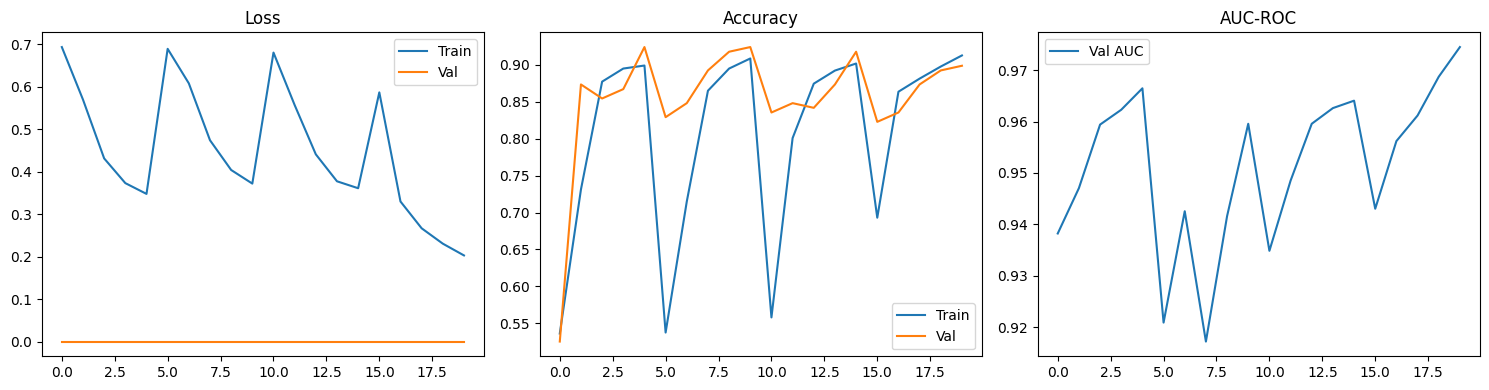


Loading best model for testing...
Test AUC: 0.9689


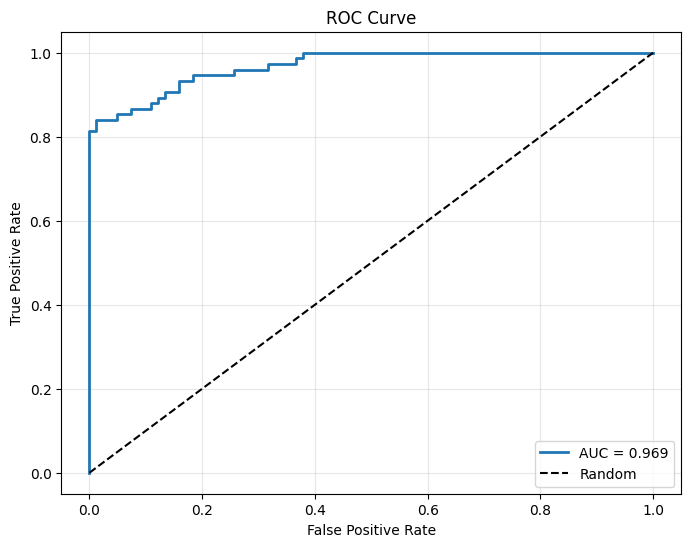

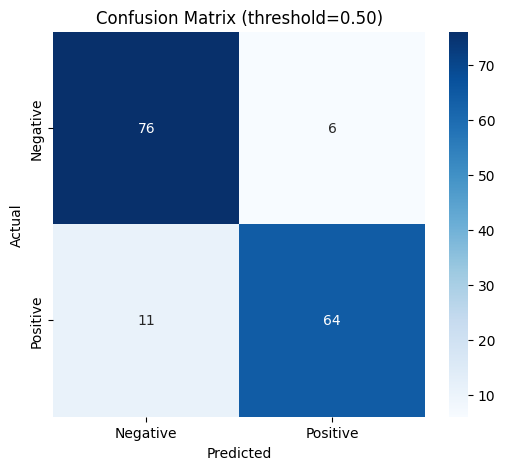

              precision    recall  f1-score   support

    Negative       0.87      0.93      0.90        82
    Positive       0.91      0.85      0.88        75

    accuracy                           0.89       157
   macro avg       0.89      0.89      0.89       157
weighted avg       0.89      0.89      0.89       157



In [32]:
# Hyper Parameter
LR = 1e-5
BATCH_SIZE = 1 # Batch Size 必須等於 1 ，因為 PyTorch 的 Tensor 必須是對齊的矩陣。如果 Bag A 有 100 個 patches，Bag B 有 50 個 patches，它們不能疊在一起變成 [2, ?, 512]。
EPOCHS = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# --- Initialize Model, Optimizer, Loss ---
model = DualAttentionMIL(input_dim=512).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-6)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.BCELoss()

# --- Best Model Tracking ---
best_val_auc = 0
save_path = ROOT / "best_mil_model.pth"

early_stopping_patience = 5
no_improve_count = 0

print(f"Training on {DEVICE}...")

# --- Training Loop ---
for epoch in range(EPOCHS):
    # ================= Training =================
    model.train()
    train_loss = 0
    train_correct = 0
    
    for bag, label in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        bag = bag.to(DEVICE)
        label = label.to(DEVICE)
        
        optimizer.zero_grad()
        output, _ = model(bag)
        
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        pred = (output > 0.5).float()
        train_correct += (pred == label).sum().item()
        
    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = train_correct / len(train_loader)
    
    # ================= Validation =================
    # 使用我們之前寫好的 evaluate_model
    val_result = evaluate_model(model, val_loader, DEVICE)
    
    # 計算 Validation Accuracy
    val_preds = (val_result['probs'] >= 0.5).astype(int)
    val_acc = (val_preds == val_result['labels']).mean()
    
    # 紀錄 History
    history.log(avg_train_loss, avg_train_acc, 0, val_acc, val_result['auc'])
    
    print(f"Epoch {epoch+1} | "
          f"Train Loss: {avg_train_loss:.4f} Acc: {avg_train_acc:.4f} | "
          f"Val Acc: {val_acc:.4f} AUC: {val_result['auc']:.4f}")
    
    # Save Best Model
    if val_result['auc'] > best_val_auc:
        best_val_auc = val_result['auc']
        torch.save(model.state_dict(), save_path)
        print(f"  >>> Best AUC! Model saved to {save_path}")
    
    if val_result['auc'] > best_val_auc:
        best_val_auc = val_result['auc']
        torch.save(model.state_dict(), save_path)
        no_improve_count = 0
    else:
        no_improve_count += 1
        if no_improve_count >= early_stopping_patience:
            print("Early stopping!")
            break

print("\nTraining Finished!")
history.plot()

# ================= Test =================
print("\nLoading best model for testing...")
model.load_state_dict(torch.load(save_path))
test_result = evaluate_model(model, test_loader, DEVICE)
print(f"Test AUC: {test_result['auc']:.4f}")

plot_roc_curve(test_result)
plot_confusion_matrix(test_result, threshold=0.5)


In [33]:
import pandas as pd
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch

def generate_all_heatmaps(model, test_loader, output_dir,target=10, device=DEVICE):
    '''
    對 test_loader 中的所有樣本產生 Attention Heatmap 並儲存
    
    Args:
        model: 訓練好的 MIL 模型
        test_loader: 測試資料的 DataLoader
        output_dir: 輸出資料夾路徑
    '''
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    model.eval()
    num = 0
    # test_loader 的 dataset 裡有 (path, label) 配對
    for idx, (bag_tensor, label) in enumerate(test_loader):
        # 取得這個 bag 的路徑資訊
        if num < target:
            num += 1
        else:
            break
        pt_path, true_label = test_loader.dataset.data_list[idx]
        bag_name = pt_path.stem  # e.g., "123"
        
        # 判斷是 positive 還是 negative
        is_positive = "positive" in str(pt_path)
        label_str = "pos" if is_positive else "neg"
        
        # 原始圖片資料夾 (存放 patches 和 coords.csv 的地方)
        if is_positive:
            original_bag_dir = DATASET_POSITIVE_TILED_DIR / bag_name
            raw_image_path = RAW_POSITIVE_IMAGES_ROOT / f"{bag_name}.png"
        else:
            original_bag_dir = DATASET_NEGATIVE_TILED_DIR / bag_name
            raw_image_path = RAW_NEGATIVE_IMAGES_ROOT / f"{bag_name}.png"
        
        # 嘗試多種副檔名
        for ext in ['.png']:
            candidate = raw_image_path.with_suffix(ext)
            if candidate.exists():
                raw_image_path = candidate
                break
        
        # 讀取座標
        coords_file = original_bag_dir / "coords.csv"
        if not coords_file.exists():
            print(f"⚠️ Skip {bag_name}: coords.csv not found")
            continue
        
        coords_df = pd.read_csv(coords_file)
        patch_coords = list(zip(coords_df['x'], coords_df['y']))
        
        # 推論
        with torch.no_grad():
            bag_tensor = bag_tensor.to(device)
            prob, attention = model(bag_tensor)
        
        attention = attention.squeeze().cpu().numpy()
        attention = attention ** 0.5
        pred_prob = prob.item()
        pred_label = "pos" if pred_prob > 0.5 else "neg"
        
        # 讀取原圖
        if not raw_image_path.exists():
            print(f"⚠️ Skip {bag_name}: raw image not found")
            continue
            
        original_img = np.array(Image.open(raw_image_path).convert('RGB'))
        h, w = original_img.shape[:2]
        
        # 建立 heatmap
        heatmap = np.zeros((h, w), dtype=np.float32)
        for i, (x, y) in enumerate(patch_coords):
            if i < len(attention):
                heatmap[y:y+SLICE_HEIGHT, x:x+SLICE_WIDTH] += attention[i]
        
        # 正規化
        if heatmap.max() > heatmap.min():
            heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
        
        # 畫圖
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        axes[0].imshow(original_img)
        axes[0].set_title('Original')
        axes[0].axis('off')
        
        axes[1].imshow(heatmap, cmap='jet')
        axes[1].set_title('Attention Heatmap')
        axes[1].axis('off')
        
        axes[2].imshow(original_img)
        axes[2].imshow(heatmap, cmap='jet', alpha=0.5)
        axes[2].set_title(f'Overlay\nTrue: {label_str} | Pred: {pred_label} ({pred_prob:.2f})')
        axes[2].axis('off')
        
        plt.tight_layout()
        
        # 儲存
        save_name = f"{bag_name}_true-{label_str}_pred-{pred_label}_{pred_prob:.2f}.png"
        plt.savefig(output_path / save_name, dpi=100, bbox_inches='tight')
        plt.close()
        
        print(f"✓ [{idx+1}/{len(test_loader)}] Saved: {save_name}")
        # break
    
    print(f"\n🎉 Done! All heatmaps saved to: {output_path}")


In [34]:
generate_all_heatmaps(model, test_loader, ROOT / "heatmaps_test")

✓ [1/157] Saved: 398_true-neg_pred-neg_0.30.png
✓ [2/157] Saved: 412_true-pos_pred-pos_0.99.png
✓ [3/157] Saved: 145_true-neg_pred-neg_0.02.png
✓ [4/157] Saved: 203_true-pos_pred-pos_0.97.png
✓ [5/157] Saved: 74_true-pos_pred-pos_1.00.png
✓ [6/157] Saved: 198_true-pos_pred-neg_0.26.png
✓ [7/157] Saved: 80_true-neg_pred-neg_0.15.png
✓ [8/157] Saved: 153_true-pos_pred-pos_0.55.png
✓ [9/157] Saved: 324_true-neg_pred-neg_0.03.png
✓ [10/157] Saved: 21_true-neg_pred-neg_0.02.png

🎉 Done! All heatmaps saved to: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/heatmaps_test
